# 암호화 트래픽 2분류 (bulk / control)

TLS 1.3으로 암호화된 세션을 복호화 없이, 패킷 크기·도착 간격·세션 길이 통계만으로 분류한다.

- 사이트 4개를 2개 그룹으로 라벨링: `steamstatic.com`·`wistia.com` → **bulk**, `google.com`·`twitter.com` → **control**
- 사이트당 300개 무작위 샘플링 → 총 1,200개 (클래스당 600개, 균형)
- 특징 9개, RandomForest(n=100), 8:2 stratified split
- **결과: 정확도 97.08%** (아래 셀 출력)

3분류(control/video/download) 확장 실험은 `data/` 의 CSV와 `apps/dashboard.py` 참고.


In [ ]:
import os
import random

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scapy.all import rdpcap, IP
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. 시각화 스타일 설정
sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 라벨용. 다른 OS면 사용 가능한 폰트로 교체
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 경로 및 샘플링 설정
#    pcap 원본은 용량이 커서 저장소에 포함하지 않는다 (README의 '데이터' 절 참고).
#    아래 경로에 사이트별 하위 폴더가 있어야 한다.
base_path = os.environ.get("ORAN_PCAP_DIR", os.path.join("data", "raw", "mix"))
samples_per_site = 300      # 각 사이트당 최대 300개씩 랜덤으로 뽑음
min_data_size = 0           # 이 크기(byte) 미만 pcap은 건너뜀
random.seed(42)             # 샘플링 재현용

# 3. 타겟 사이트 및 라벨 정의 (연구자의 설계)
target_sites = {
    # --- Bulk 그룹 (고대역폭) ---
    "steamstatic.com": "bulk",  # 게임 다운로드
    "wistia.com": "bulk",       # 비디오 스트리밍

    # --- Control 그룹 (저대역폭) ---
    "google.com": "control",    # 검색
    "twitter.com": "control"    # 텍스트 SNS
}

print(f"설정 완료! 경로: {base_path}")
print(f"목표: 사이트당 {samples_per_site}개 랜덤 샘플링")


In [36]:
def extract_features(file_path):
    try:
        # [노이즈 제거 1단계] 파일 크기가 너무 작으면 읽지도 않고 패스 (속도 향상)
        if os.path.getsize(file_path) < min_data_size:
            return None 

        # Pcap 읽기
        packets = rdpcap(file_path)
        ip_packets = [pkt for pkt in packets if IP in pkt]
        
        # [노이즈 제거 2단계] 실제 패킷이 너무 적으면 패스
        if len(ip_packets) < 5: return None
        
        # --- 통계 계산 ---
        sizes = [pkt[IP].len for pkt in ip_packets]
        timestamps = [float(pkt.time) for pkt in ip_packets]
        deltas = np.diff(timestamps)
        
        return {
            "avg_pkt_size": np.mean(sizes),
            "std_pkt_size": np.std(sizes),
            "max_pkt_size": np.max(sizes),
            "min_pkt_size": np.min(sizes),
            "avg_delta_time": np.mean(deltas) if len(deltas) > 0 else 0,
            "std_delta_time": np.std(deltas) if len(deltas) > 0 else 0,
            "max_delta_time": np.max(deltas) if len(deltas) > 0 else 0,
            "duration": timestamps[-1] - timestamps[0] if len(timestamps) > 0 else 0,
            "total_packets": len(ip_packets)
        }
    except Exception as e:
        return None # 파일 깨짐 등 오류 발생 시 무시

In [37]:
data = []
print(f" 자동화 파이프라인")

for site, label in target_sites.items():
    site_path = os.path.join(base_path, site)
    
    if os.path.exists(site_path):
        # 해당 폴더의 모든 pcap 파일 목록 가져오기
        all_files = [f for f in os.listdir(site_path) if f.endswith(".pcap")]
        
        # ★ 핵심: 무작위로 섞기 (Random Shuffle)
        random.shuffle(all_files)
        
        print(f" [{site}] 폴더 진입... (총 {len(all_files)}개 중 유효 데이터 탐색)")
        
        count = 0
        for file in all_files:
            # 특징 추출 시도
            features = extract_features(os.path.join(site_path, file))
            
            if features:
                features['class'] = label
                data.append(features)
                count += 1
            
            # 목표 개수(300개)를 채우면 그만 뽑고 다음 사이트로 이동
            if count >= samples_per_site:
                break
        
        print(f"   L  {count}개 유효 데이터 확보 완료")
    else:
        print(f"⚠️ 경고: {site} 폴더가 없습니다. 경로를 확인하세요.")

# 데이터프레임 변환 및 확인
df = pd.DataFrame(data)
print("-" * 50)
print(f" 최종 데이터셋 생성 완료: 총 {len(df)}개")
print(df['class'].value_counts())
display(df.head())

 자동화 파이프라인
 [steamstatic.com] 폴더 진입... (총 863개 중 유효 데이터 탐색)
   L  300개 유효 데이터 확보 완료
 [wistia.com] 폴더 진입... (총 884개 중 유효 데이터 탐색)
   L  300개 유효 데이터 확보 완료
 [google.com] 폴더 진입... (총 805개 중 유효 데이터 탐색)
   L  300개 유효 데이터 확보 완료
 [twitter.com] 폴더 진입... (총 805개 중 유효 데이터 탐색)
   L  300개 유효 데이터 확보 완료
--------------------------------------------------
 최종 데이터셋 생성 완료: 총 1200개
class
bulk       600
control    600
Name: count, dtype: int64


,avg_pkt_size,std_pkt_size,max_pkt_size,min_pkt_size,avg_delta_time,std_delta_time,max_delta_time,duration,total_packets,class
0,243.500000,631.347646,2920,40,0.002269,0.004329,0.019260,0.043114,20,bulk
1,224.909091,604.730286,2920,40,0.002546,0.005026,0.019404,0.053469,22,bulk
2,254.526316,646.110172,2920,40,0.001511,0.002577,0.009703,0.027198,19,bulk
3,1351.973684,2035.800056,8680,40,0.015480,0.053701,0.305592,0.572765,38,bulk
4,233.761905,429.067306,1480,40,0.001854,0.003670,0.015376,0.037090,21,bulk


In [38]:
if len(df) > 0:
    # 1. 데이터 분리
    X = df.drop("class", axis=1)
    y = df["class"]
    
    # 2. 훈련/테스트 분리 (8:2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # 3. 모델 학습
    print(" 모델 학습 중...")
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    print(" 학습 완료!")
else:
    print("❌ 데이터가 없어서 학습할 수 없습니다. 경로를 다시 확인해주세요.")

 모델 학습 중...
 학습 완료!



 [최종 검증 결과]
정확도 (Accuracy): 97.08%
------------------------------
              precision    recall  f1-score   support

        bulk       0.96      0.98      0.97       120
     control       0.98      0.96      0.97       120

    accuracy                           0.97       240
   macro avg       0.97      0.97      0.97       240
weighted avg       0.97      0.97      0.97       240



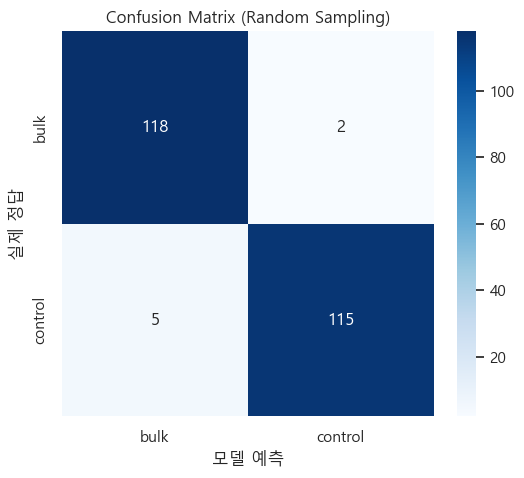

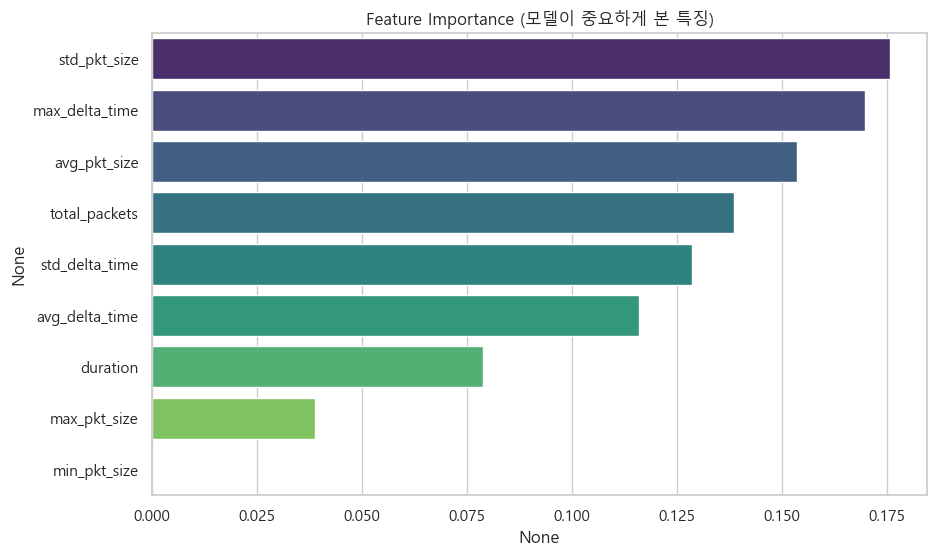

In [39]:
if len(df) > 0:
    # 1. 예측
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # 2. 결과 출력
    print(f"\n [최종 검증 결과]")
    print(f"정확도 (Accuracy): {accuracy * 100:.2f}%")
    print("-" * 30)
    print(classification_report(y_test, y_pred))
    
    # 3. 오차 행렬 시각화
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title('Confusion Matrix (Random Sampling)')
    plt.ylabel('실제 정답')
    plt.xlabel('모델 예측')
    plt.show()
    
    # 4. 특성 중요도 확인
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=imp, y=imp.index, palette="viridis")
    plt.title('Feature Importance (모델이 중요하게 본 특징)')
    plt.show()